### Etapa I: Caracterizaci´on Estoc´astica y Frecuencial

In [258]:
import numpy as np
from scipy.io import wavfile
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import firwin, cheby2, freqz, sosfilt, iirfilter, spectrogram, welch, freqz_zpk, kaiserord, cheb2ord


In [259]:
sr, complete_signal = wavfile.read("data/signal.wav")
complete_signal = complete_signal[:, 0] 

In [260]:
print(f"Frecuencia de muestreo: {sr}")

Frecuencia de muestreo: 48000


■ Visualizaci´on y Potencia: Graficar las se˜nales en el dominio temporal y esti-
mar su Densidad Espectral de Potencia (PSD) utilizando estimadores espectrales.
A partir de esto, se debe determinar la potencia total de la se˜nal e identificar
cu´ales son las bandas de frecuencia espec´ıficas que concentran la mayor cantidad
de energ´ıa.

Text(0.5, 0, 'muestras')

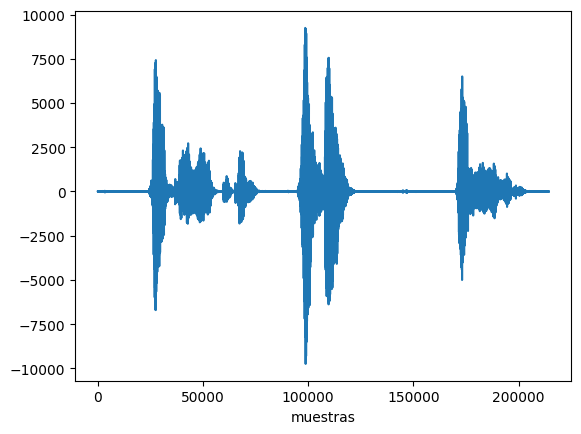

In [261]:
dur = len(complete_signal) / sr
t = np.linspace(0, dur, len(complete_signal))

sns.lineplot(complete_signal)
plt.xlabel("muestras")


Text(0.5, 1.0, 'Densidad Espectral de Potencia')

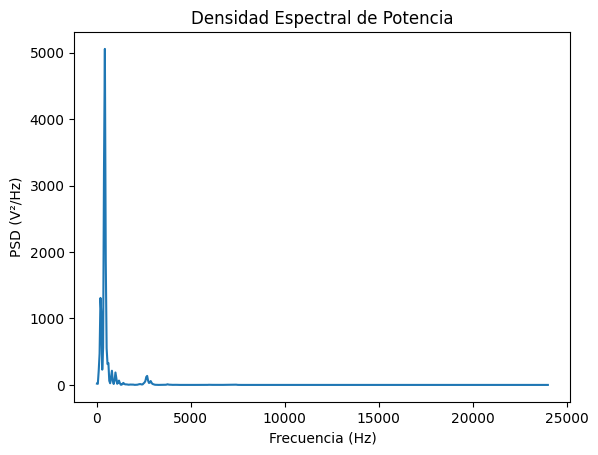

In [262]:
f, psd = welch(complete_signal, fs=sr, nperseg=1024)

plt.plot(f, psd)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Densidad Espectral de Potencia")

Vamos a "hacer zoom" hasta 5000Hz

Text(0.5, 1.0, 'Densidad Espectral de Potencia')

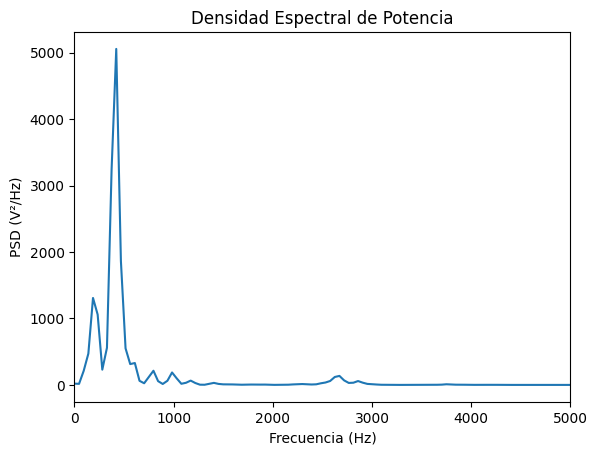

In [263]:
plt.plot(f, psd)
plt.xlim(0,5000)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Densidad Espectral de Potencia")

In [264]:
potencia = np.mean(complete_signal**2)

print(f"Potencia de la señal: {potencia:.2f}W")

Potencia de la señal: 1093.90W


Text(0.5, 1.0, 'Espectrograma')

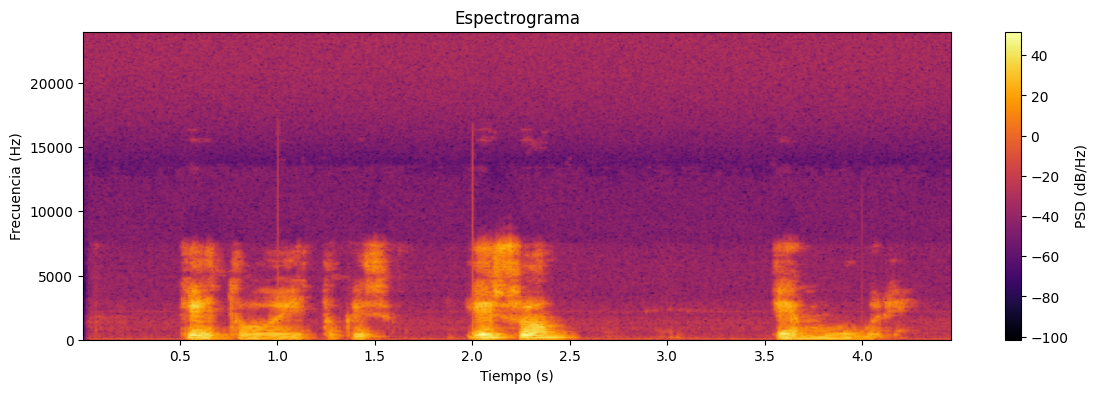

In [265]:
f, t, Sxx = spectrogram(complete_signal, fs=sr, nperseg=512)

plt.figure(figsize=(14, 4))
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='inferno')
plt.ylabel("Frecuencia (Hz)")
plt.xlabel("Tiempo (s)")
plt.colorbar(label="PSD (dB/Hz)")
plt.title("Espectrograma")

Como es de esperar, al tratarse de una señal de voz, la energía se concetra en las frecuencias bajas

 Estacionariedad: Justificar de forma te´orica y pr´actica si las se˜nales asignadas
pueden considerarse Estacionarias en Sentido Amplio (WSS, Wide-Sense Statio-
nary) y erg´odicas en toda su extensi´on, o si por el contrario deben ser analizadas
por tramos o bloques (ventanas). En caso de optar por un an´alisis segmentado, se
deber´a definir y justificar rigurosamente la duraci´on ´optima de dicha ventana.

<Axes: >

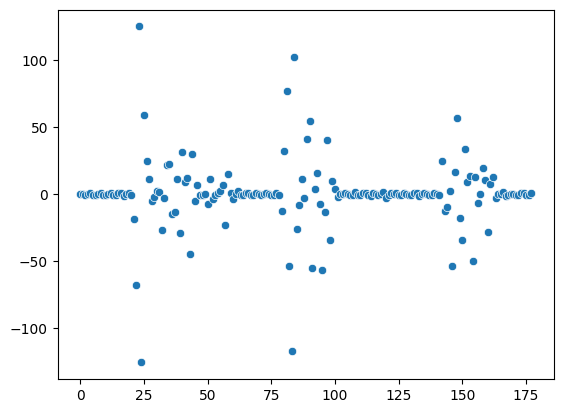

In [266]:
#Tomamos ventanas de 25ms
window_size = int(0.025 * sr)
step = window_size

medias = []

for i in range(0, len(complete_signal) - window_size, step):
    ventana = complete_signal[i:i+window_size]
    medias.append(np.mean(ventana))
    
sns.scatterplot(medias)

**No es WSS y, por ende, no es ergódica**

**Entonces, vamos a trabajar en ventanas de 20-30 ms donde podemos asumir estacionaria a la señal, esto debido a que el tracto vocal tiene una tasa de cambio de alrededor de 50-100 ms**

■ C´alculo de Entrop´ıa: Calcular la entrop´ıa de la se˜nal original para cuantificar
su contenido de informaci´on y grado de aleatoriedad. Para este c´alculo, el grupo
deber´a implementar y comparar dos metodolog´ıas: una basada en el histograma
temporal de amplitudes y otra calculada a partir de la distribuci´on del espectro de
potencia.

**Histograma temporal de amplitudes: La idea es sencilla, partimos las amplitudes en bins y contamos cuántas muestras caen en cada uno. De esta forma podemos pasar a tener probabilidades discretas y usar Shannon**

In [267]:
counts, _ = np.histogram(complete_signal, bins=64)
probs = counts / counts.sum()
probs = probs[probs > 0]  # evitar log(0)
H_amplitud = -np.sum(probs * np.log2(probs))

print(f"Entropía (calculada por amplitud): {H_amplitud:.2f} bits")

Entropía (calculada por amplitud): 2.25 bits


In [268]:
f, psd = welch(complete_signal, fs=sr, nperseg=1024)
psd_norm = psd / psd.sum()
psd_norm = psd_norm[psd_norm > 0]
H_espectral = -np.sum(psd_norm * np.log2(psd_norm))

print(f"Entropía (calculada por densidad espectral): {H_espectral:.2f} bits")

Entropía (calculada por densidad espectral): 3.65 bits


**Entonces, tenemos la información más "concentrada" en el tiempo que en frecuencia. Tiene sentido, viendo la señal y los 3 picos que presenta**

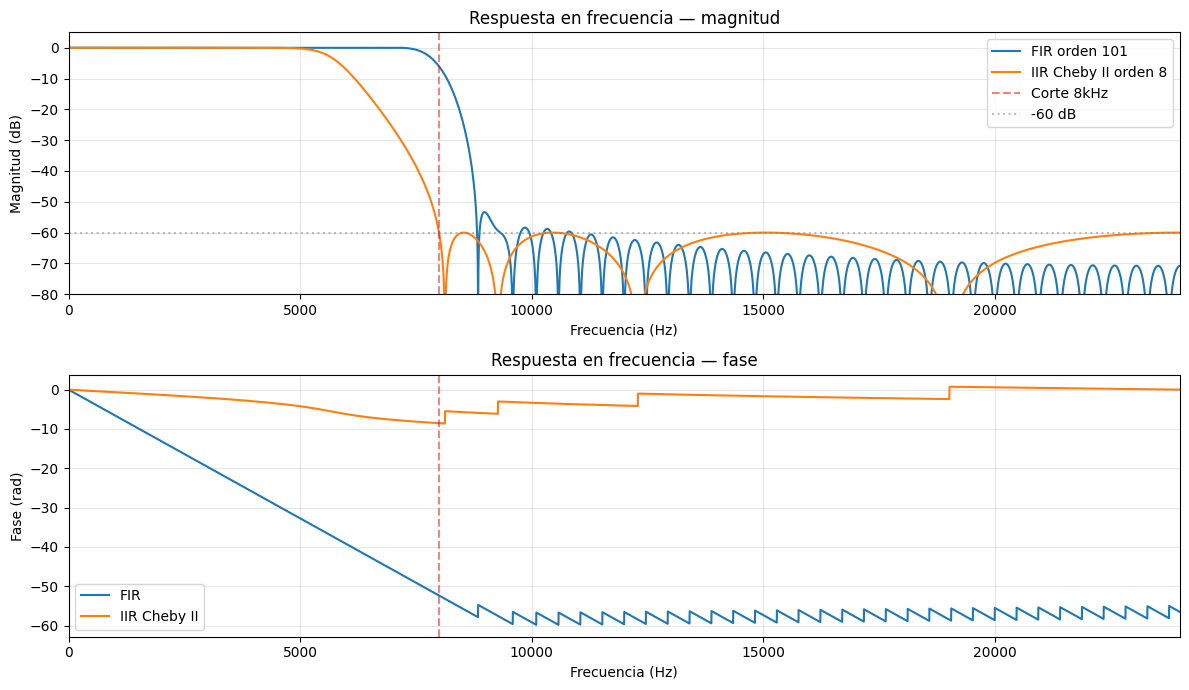

In [269]:

# Frecuencia de Nyquist
nyq = sr / 2
cutoff = 8000  # Hz

# --- FIR por ventanas (firwin) ---
order_fir = 101  # orden impar para filtro tipo I
b_fir = firwin(order_fir, cutoff / nyq, window='hamming')

# --- IIR Chebyshev tipo II ---
order_iir = 8
rs = 60  # atenuación en banda de rechazo (dB)
sos = cheby2(order_iir, rs, cutoff / nyq, btype='low', output='sos')

# --- Respuesta en frecuencia ---
w_fir, h_fir = freqz(b_fir, worN=8192)
w_iir, h_iir = freqz_zpk(*cheby2(order_iir, rs, cutoff / nyq, output='zpk'), worN=8192)

freqs_fir = w_fir * sr / (2 * np.pi)
freqs_iir = w_iir * sr / (2 * np.pi)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Magnitud
axes[0].plot(freqs_fir, 20 * np.log10(np.abs(h_fir) + 1e-10), label=f'FIR orden {order_fir}')
axes[0].plot(freqs_iir, 20 * np.log10(np.abs(h_iir) + 1e-10), label=f'IIR Cheby II orden {order_iir}')
axes[0].axvline(cutoff, color='r', linestyle='--', alpha=0.5, label='Corte 8kHz')
axes[0].axhline(-rs, color='gray', linestyle=':', alpha=0.5, label=f'-{rs} dB')
axes[0].set_xlim(0, nyq)
axes[0].set_ylim(-80, 5)
axes[0].set_xlabel("Frecuencia (Hz)")
axes[0].set_ylabel("Magnitud (dB)")
axes[0].set_title("Respuesta en frecuencia — magnitud")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fase
axes[1].plot(freqs_fir, np.unwrap(np.angle(h_fir)), label='FIR')
axes[1].plot(freqs_iir, np.unwrap(np.angle(h_iir)), label='IIR Cheby II')
axes[1].axvline(cutoff, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlim(0, nyq)
axes[1].set_xlabel("Frecuencia (Hz)")
axes[1].set_ylabel("Fase (rad)")
axes[1].set_title("Respuesta en frecuencia — fase")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Aplicar filtros ---
signal_fir = np.convolve(complete_signal, b_fir, mode='same')
signal_iir = sosfilt(sos, complete_signal)

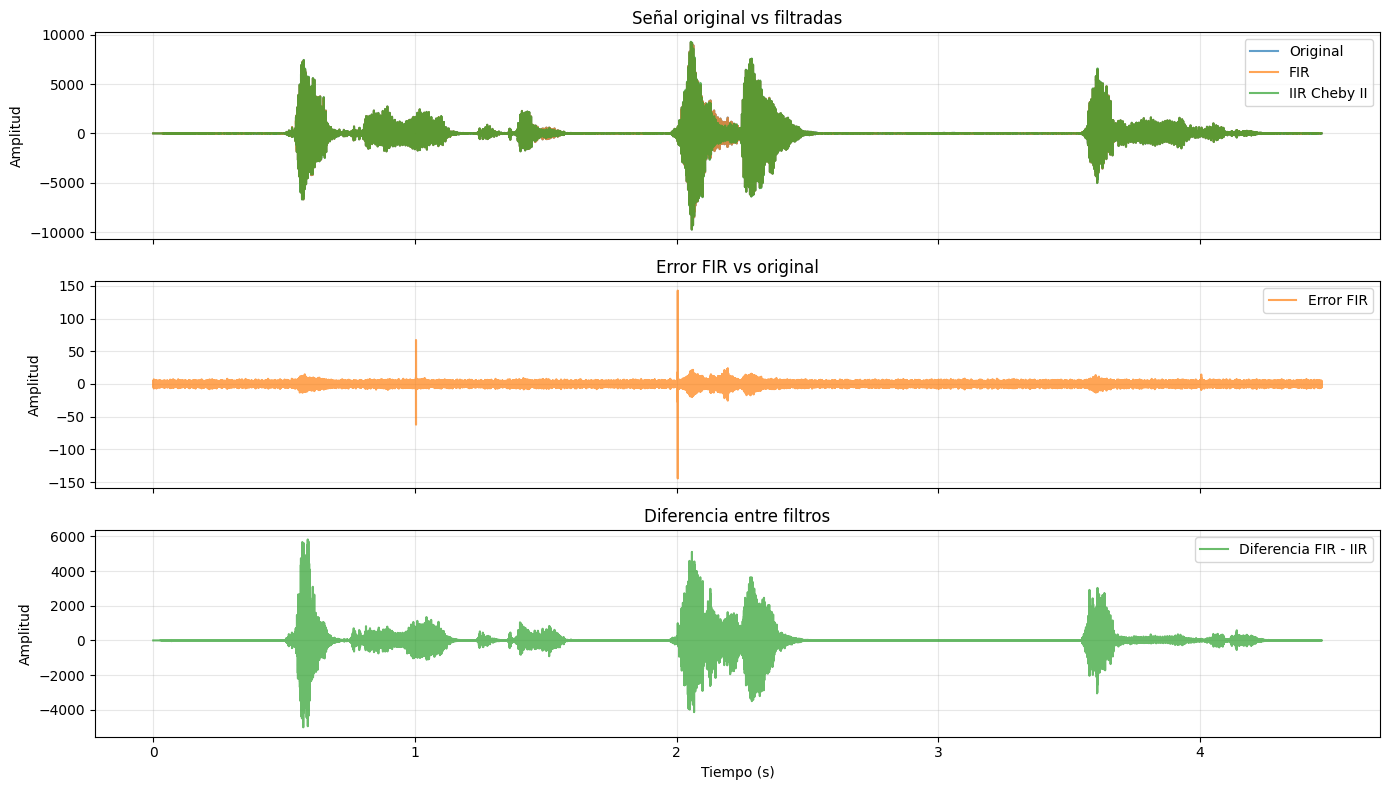

In [270]:
error = signal_fir - signal_iir

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

t = np.linspace(0, len(complete_signal) / sr, len(complete_signal))

axes[0].plot(t, complete_signal, alpha=0.7, label='Original')
axes[0].plot(t, signal_fir, alpha=0.7, label='FIR')
axes[0].plot(t, signal_iir, alpha=0.7, label='IIR Cheby II')
axes[0].set_ylabel("Amplitud")
axes[0].set_title("Señal original vs filtradas")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, signal_fir - complete_signal, color='C1', alpha=0.7, label='Error FIR')
axes[1].set_ylabel("Amplitud")
axes[1].set_title("Error FIR vs original")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, error, color='C2', alpha=0.7, label='Diferencia FIR - IIR')
axes[2].set_ylabel("Amplitud")
axes[2].set_xlabel("Tiempo (s)")
axes[2].set_title("Diferencia entre filtros")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ahora, buscamos los ordenes optimos de los filtros

In [271]:
delta_f = 1000  # ancho de banda de transición en Hz
atten_db = 60   # atenuación deseada en dB

N, beta = kaiserord(atten_db, delta_f / nyq)
print(f"Orden FIR óptimo: {N}")

b_fir = firwin(N, cutoff / nyq, window=('kaiser', beta))

Orden FIR óptimo: 176


In [272]:
wp = 8000 / nyq   # frecuencia de paso (normalizada)
ws = 9000 / nyq   # frecuencia de rechazo (normalizada)
gpass = 3         # rizado máximo en banda de paso (dB)
gstop = 60        # atenuación mínima en banda de rechazo (dB)

N, wn = cheb2ord(wp, ws, gpass, gstop)
print(f"Orden IIR óptimo: {N}")

sos = cheby2(N, gstop, wn, btype='low', output='sos')

Orden IIR óptimo: 14


**En principio, vamos a trabajar con el FIR debido a las practicidades ya conocidas: estabilidad y fase lineal. Sin embargo, no dejamos de tener en cuenta que tiene unas 12 veces más parámetros que el IIR, por lo que si llegara a resultar impráctico por el costo computacional, implementaríamos el IIR.**

2.3. Etapa III: Modelado y Compresi´on mediante Predicci´on Lineal
(LPC)
Para optimizar la transmisi´on de la se˜nal de voz a trav´es del canal, el sistema no
enviar´a la se˜nal muestreada de manera directa, sino los par´ametros estimados de un
modelo matem´atico que permita reconstruirla (sintetizarla) fielmente en el receptor. A
tal fin, se dise˜nar´a un codificador/decodificador basado en el modelo cl´asico fuente-filtro.
Los alumnos deber´an definir, analizar y justificar en su informe t´ecnico los siguientes
n´ucleos tem´aticos:

2.3.1. Intervalo de Ventaneo (An´alisis de Estacionariedad)
Due to que las caracter´ısticas fon´eticas de la voz cambian continuamente en el tiempo,
los coeficientes del filtro predictor son variantes temporales. El grupo de trabajo deber´a
determinar:
■ ¿Cada cu´antos milisegundos (ms) se deben recalcular los coeficientes LPC?
■ Justificar la elecci´on del tama˜no de la ventana en funci´on de la constante de tiempo
que tarda el tracto vocal humano en cambiar su configuraci´on anat´omica (propie-
dad de cuasi-estacionariedad).

**Vamos a tomar ventanas de 30ms, donde podemos asumir estacionaria a la señal de voz. Esto es importante ya que es una de las hipótesis más fuertes que vimos para el cálculo de los coeficientes LPC**

■ Definir qu´e tipo de ventana anal´ıtica (por ejemplo, Hamming, Hanning o Rec-
tangular) es la m´as adecuada para mitigar el efecto de spectral leakage (p´erdida
espectral) durante el c´alculo de la funci´on de autocorrelaci´on.

**Vamos a usar ventanas de Hamming, por tener un buen balance entre el ancho del lobulo central y los lobulos laterales, ya que queremos evitar el spectral leakeage en los armónicos de la frecuencia fundamental.**

2.3.2. Clasificaci´on de la Se˜nal Generadora (Excitaci´on)
Para cada tramo indexado de la se˜nal de voz, el sistema debe decidir de manera
autom´atica (ya sea mediante algoritmos l´ogicos o mediante un umbral emp´ırico basado
en el nivel de energ´ıa y la tasa de cruces por cero) qu´e tipo de sonido se est´a procesando:
■ Fonemas Sonoros (Voiced ): Correspondientes a las vocales (A, E, O, etc.).
El grupo deber´a definir cu´al es la se˜nal generadora adecuada para este escenario
(frecuencia fundamental o pitch provocado por la vibraci´on de las cuerdas locales)
y describir c´omo estimar con precisi´on dicho per´ıodo de repetici´on T0.
■ Fonemas Sordos (Unvoiced ): Correspondientes a consonantes fricativas (S, F,
P, etc.). El grupo deber´a definir qu´e tipo de proceso estoc´astico o se˜nal generadora
modela adecuadamente el paso del aire turbulento a trav´es del tracto vocal sin
vibraci´on de las cuerdas.

**Vamos a buscar los umbrales**

In [ ]:
def autocorrelacion(x):
    N = len(x)
    r = np.zeros(N+N-1)

    for n in range(N+N-1):
        lag = n - (N - 1)
        for k in range(N):
            indice_desplazado = k + lag
            if 0 <= indice_desplazado < N:
                r[n] += x[k] * x[indice_desplazado]
    return r


def levinson_durbin(r, p):
    a = np.zeros((p + 1, p + 1))
    k = np.zeros(p + 1)
    E = np.zeros(p + 1)

    E[0] = r[0]

    for i in range(1, p + 1):

      # 1 <= i <= p
      suma = 0
      for j in range(1, i):
          suma += a[j, i-1] * r[i-j]

      k[i] = - (r[i] + suma) / E[i-1]

      # 2
      a[i, i] = k[i]

      # 3 para 1 <= j <= i-1
      for j in range(1, i):
          a[j, i] = a[j, i-1] + k[i] * a[i-j, i-1]

      # 4
      E[i] = E[i-1] * (1 - k[i]**2)

    coeficientes_finales = a[1:, p]

    return coeficientes_finales, E, a

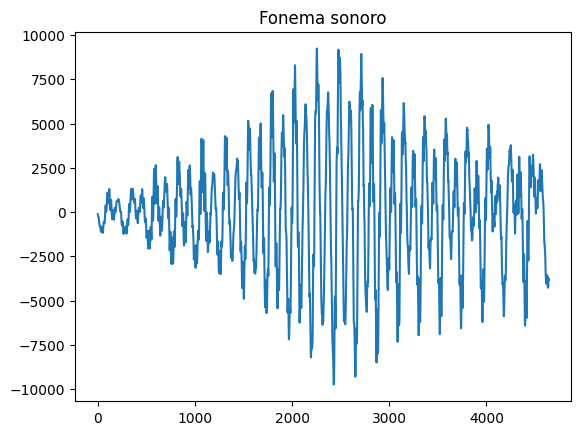

energia_sonoro: 16.131193451098664
zcr_sonoro: 0.02671837965955613


In [315]:
sr, fonema_sonoro = wavfile.read("data/fonema-sonoro-dipe.wav")
fonema_sonoro = fonema_sonoro[:, 0]

energia_sonoro = np.mean(fonema_sonoro**2)
zcr_sonoro = np.mean(np.abs(np.diff(np.sign(fonema_sonoro))) / 2)

sns.lineplot(fonema_sonoro)
plt.title("Fonema sonoro")
plt.show()

print(f"energia_sonoro: {energia_sonoro}")
print(f"zcr_sonoro: {zcr_sonoro}")

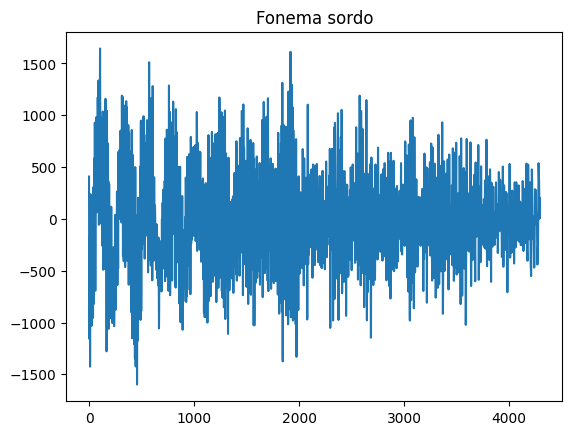

energia_sordo: 2296.30607966457
zcr_sordo: 0.19757688723205966


In [316]:
sr, fonema_sordo = wavfile.read("data/fonema-sordo-dipe.wav")
fonema_sordo = fonema_sordo[:, 0]

energia_sordo = np.mean(fonema_sordo**2)
zcr_sordo = np.mean(np.abs(np.diff(np.sign(fonema_sordo))) / 2)

sns.lineplot(fonema_sordo)
plt.title("Fonema sordo")
plt.show()

print(f"energia_sordo: {energia_sordo}")
print(f"zcr_sordo: {zcr_sordo}")

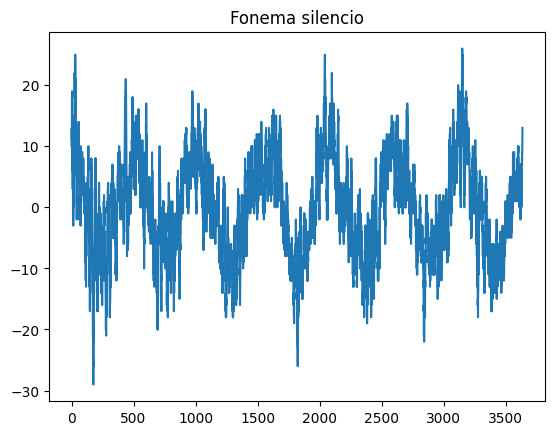

energia_silencio: 66.19312242090784
zcr_silencio: 0.16070445789763346


In [317]:
sr, silencio = wavfile.read("data/silencio-dipe.wav")
silencio = silencio[:, 0]

energia_silencio = np.mean(silencio**2)
zcr_silencio = np.mean(np.abs(np.diff(np.sign(silencio))) / 2)

sns.lineplot(silencio)
plt.title("Fonema silencio")
plt.show()

print(f"energia_silencio: {energia_silencio}")
print(f"zcr_silencio: {zcr_silencio}")

In [318]:
sr, fonema_sonoro = wavfile.read("data/fonema-sonoro-dipe.wav")
fonema_sonoro = fonema_sonoro[:, 0]

energia_sonoro = np.mean(fonema_sonoro**2)
zcr_sonoro = np.mean(np.abs(np.diff(np.sign(fonema_sonoro))) / 2)

In [319]:
def clasificar_frame(ventana):
    energia = np.mean(ventana**2)
    zcr = np.mean(np.abs(np.diff(np.sign(ventana))) / 2)
    
    if energia < 100 and zcr < 0.05:
        return 'sonoro'
    elif energia < 200:
        return 'silencio'
    else:
        return 'sordo'

In [ ]:
def obtener_T0(ventana):
    f0_min, f0_max = 100, 300
    lag_min = int(sr / f0_max)
    lag_max = int(sr / f0_min)
    
    cep = np.fft.ifft(np.log(np.abs(np.fft.fft(ventana))+ 1e-10)).real
    lag_pico = np.argmax(cep[lag_min:lag_max]) + lag_min
    T0 = lag_pico / sr
    
    return T0